In [1]:
!pip install keras keras-hub --upgrade -q
import os
os.environ["KERAS_BACKEND"] = "jax"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.21.1 requires keras-hub==0.21.1, but you have keras-hub 0.23.0 which is incompatible.


In [2]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

In [3]:
from keras.datasets import fashion_mnist as cifar10

# Load the dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


In [4]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

In [5]:
import keras
from keras import layers
from keras.layers import Input

model = keras.Sequential([
    Input(shape=(784,)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer="nadam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [8]:
x_train.shape

(60000, 784)

In [9]:
x_val = x_train[-10000:]
y_val = y_train[-10000:]

x_train = x_train[:50000]
y_train = y_train[:50000]

In [10]:
y_train.shape

(50000,)

In [11]:
history = model.fit(
    x_train,
    y_train,
    epochs=40,
    batch_size=64,
    validation_data=(x_val, y_val),
    validation_batch_size=128
)

Epoch 1/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8316 - loss: 0.4695 - val_accuracy: 0.8601 - val_loss: 0.3972
Epoch 2/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8728 - loss: 0.3506 - val_accuracy: 0.8707 - val_loss: 0.3532
Epoch 3/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8834 - loss: 0.3159 - val_accuracy: 0.8623 - val_loss: 0.3833
Epoch 4/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8902 - loss: 0.2942 - val_accuracy: 0.8798 - val_loss: 0.3330
Epoch 5/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8980 - loss: 0.2754 - val_accuracy: 0.8859 - val_loss: 0.3231
Epoch 6/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9023 - loss: 0.2615 - val_accuracy: 0.8872 - val_loss: 0.3132
Epoch 7/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9078 - loss: 0.2469 - val_accuracy: 0.8874 - val_loss: 0.3136
Epoch 8/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9129 - loss: 0.2352 - val_accur

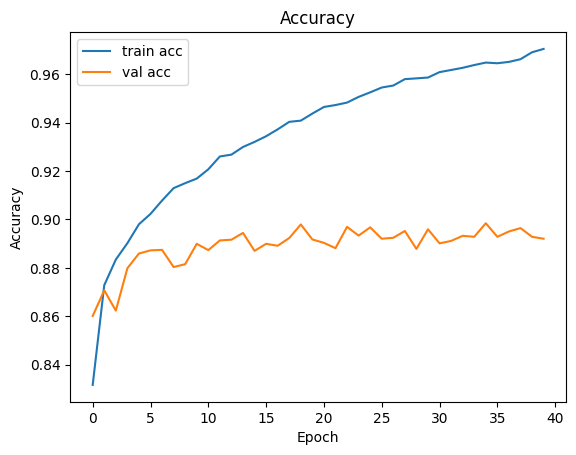

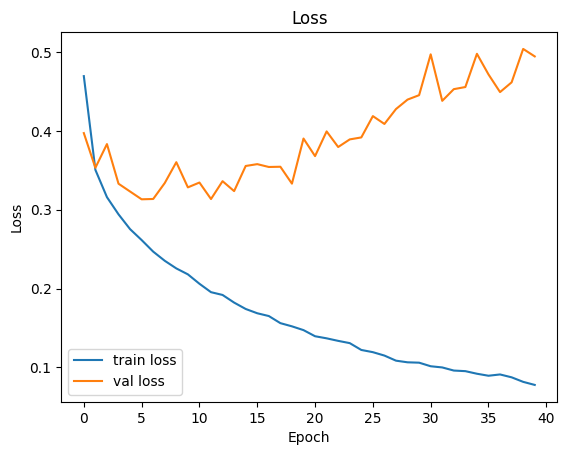

In [12]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [13]:
# We retrain the model to the optimal epochs to avoid overfitting

new_model = keras.Sequential([
    Input(shape=(784,)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

new_model.compile(
    optimizer="nadam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = new_model.fit(
    x_train,
    y_train,
    epochs=1,
    batch_size=64,
    validation_data=(x_val, y_val),
    validation_batch_size=128
)

782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.8317 - loss: 0.4689 - val_accuracy: 0.8623 - val_loss: 0.3819


In [14]:
#output model
new_model.save('MNist_FCNN_cifar10_0_8317_nadam.keras')